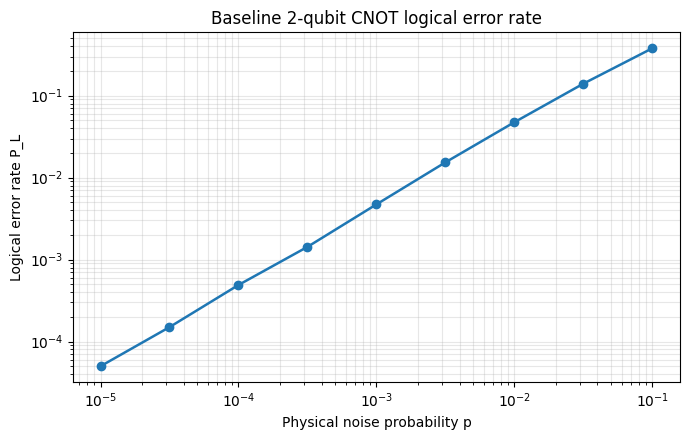

Saved baseline rates to: /Users/lenny/Documents/foo/EPIC-QEC/docs/example_notebooks/cnot_benchmark_result/logical_rates/baseline_2q_cnot_rates.npz
p=1.00e-05 -> P_L=0.000050
p=3.16e-05 -> P_L=0.000150
p=1.00e-04 -> P_L=0.000490
p=3.16e-04 -> P_L=0.001430
p=1.00e-03 -> P_L=0.004720
p=3.16e-03 -> P_L=0.015380
p=1.00e-02 -> P_L=0.047510
p=3.16e-02 -> P_L=0.140290
p=1.00e-01 -> P_L=0.379420
Loaded metadata:
  title: Baseline 2-qubit CNOT logical error rate
  description: Logical failure probability for a 2-qubit |00> -> CNOT -> ZZ readout baseline. A shot is a logical fail when measured bits are not 00. Noise uses EPIC StimLikeNoiseModel with matched p for reset flip, Clifford depolarization, and pre-measurement flip channels.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import stim

from pathlib import Path
from epic import StimLikeNoiseModel

# Baseline experiment: initialize |00>, apply CNOT, then measure both qubits in Z basis.
base_program = """
R 0 1
CX 0 1
M 0 1
""".strip()

noise_values = np.logspace(-5, -1, 9)
shots = 100_000
logical_error_rates = []

for p in noise_values:
    noise_model = StimLikeNoiseModel.from_stim_like_probabilities(
        after_clifford_depolarization=float(p),
        after_reset_flip_probability=float(p),
        before_measure_flip_probability=float(p),
    )
    noisy_program = noise_model.apply_model(base_program)
    circuit = stim.Circuit(noisy_program)

    samples = circuit.compile_sampler().sample(shots=shots)
    logical_failures = np.any(samples.astype(np.uint8), axis=1)
    logical_error_rates.append(float(np.mean(logical_failures)))

logical_error_rates = np.array(logical_error_rates)

result_title = "Baseline 2-qubit CNOT logical error rate"
result_description = (
    "Logical failure probability for a 2-qubit |00> -> CNOT -> ZZ readout baseline. "
    "A shot is a logical fail when measured bits are not 00. "
    "Noise uses EPIC StimLikeNoiseModel with matched p for reset flip, "
    "Clifford depolarization, and pre-measurement flip channels."
)

results_path = Path("baseline_2q_cnot_rates.npz")
results_path.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    results_path,
    noise_values=noise_values,
    logical_error_rates=logical_error_rates,
    shots=np.array([shots], dtype=np.int64),
    title=np.array([result_title]),
    description=np.array([result_description]),
)

plt.figure(figsize=(7, 4.5))
plt.plot(noise_values, logical_error_rates, marker="o", linewidth=1.8)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Physical noise probability p")
plt.ylabel("Logical error rate P_L")
plt.title(result_title)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Saved baseline rates to: {results_path.resolve()}")
for p, pl in zip(noise_values, logical_error_rates):
    print(f"p={p:.2e} -> P_L={pl:.6f}")

# Fast load pattern for later plotting:
loaded = np.load(results_path)
print("Loaded metadata:")
print(f"  title: {loaded['title'][0]}")
print(f"  description: {loaded['description'][0]}")